# 1. 拡散モデルを用いた反事実的画像編集

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn.functional as F
import itertools
from tqdm.auto import tqdm

In [2]:
from diffusion.diffusion_model.models.model9 import UNet
from diffusion.utils.utils import load_checkpoint
import json


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-04-28_18/config_20250428.json"
with open(file_path, mode='r') as f:
    config = json.load(f)


epochs = config['epochs']
timesteps = config['timesteps']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)

In [3]:
# checkpointの読み込み
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename='/home/hashikami/checkpoint/checkpoint_2025-04-28_18.pth')

In [30]:
# metricsのサンプルを取得

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from dataset.morphomnist import MorphoMNISTLike

# Example usage
batch_size = 1
dataset = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/MorphoMNIST",
                            columns=['intensity', 'thickness'], train=False)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
intensity = next(iter(data_loader))['intensity'][:, None].float()
thickness = next(iter(data_loader))['thickness'][:, None].float()
metrics = torch.cat([intensity, thickness], dim=1).to(device)
images = next(iter(data_loader))['image'] / 255.0

"""
fig, axes = plt.subplots(1, batch_size, figsize=(15, 3))
for i in range(batch_size):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
plt.show()
print(metrics)
"""

"\nfig, axes = plt.subplots(1, batch_size, figsize=(15, 3))\nfor i in range(batch_size):\n    axes[i].imshow(images[i].squeeze(), cmap='gray')\nplt.show()\nprint(metrics)\n"

## 1.1 条件付き生成

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

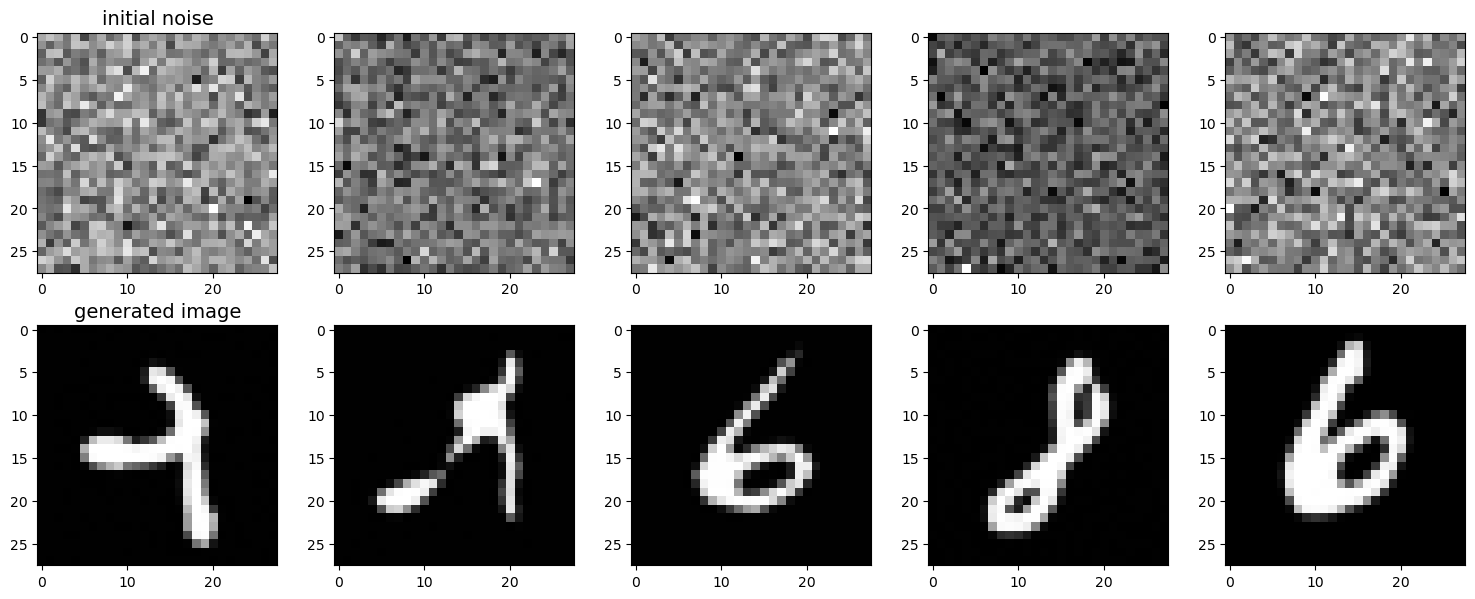

In [8]:
import importlib
from diffusion.utils import sample

importlib.reload(sample)

from diffusion.utils.sample import conditional_ddim_plot_samples


conditional_ddim_plot_samples(denoise_model, eta=1.0, interval=1, cond=metrics, w=0.1, image_size=28, batch_size=5, timesteps=500)

## 1.2 介入後条件付き画像編集

### 1.2.1 複数枚で編集

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

IndexError: index 1 is out of bounds for dimension 0 with size 1

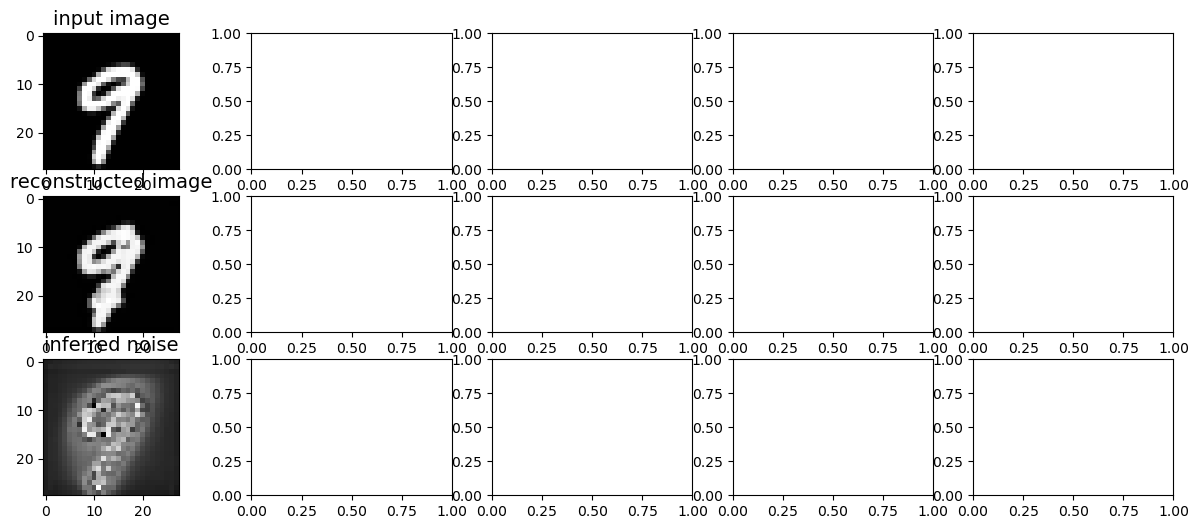

In [14]:
from diffusion.utils import sample
import importlib

importlib.reload(sample)

from diffusion.utils.sample import conditional_ddim_plot_samples

conditional_ddim_plot_samples(denoise_model, eta=0.0, interval=1, cond=metrics, w=5.0, batch_size=5, image_size=28, timesteps=500, reverse=True, input_img=images.unsqueeze(1).to(device), intervened_cond=intervened_metrics)

### 1.2.2 1枚の画像をガイダンススケール固定で様々な介入条件で編集

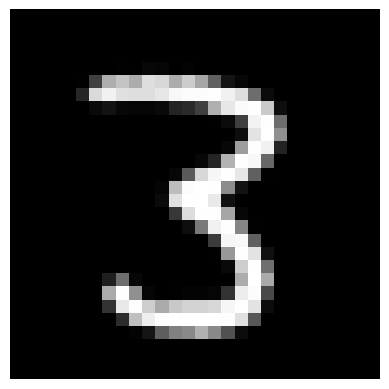

In [31]:
plt.imshow(images[0].squeeze(), cmap='gray')
plt.axis('off')
plt.show()


In [39]:
metrics

tensor([[120.6711,   2.4086]], device='cuda:0')

In [35]:
intensity_values = [80.6711, 100.6711, 120.6711, 170.6711, 220.6711]
thickness_values = [1.6086, 2.0086, 2.4086, 2.9086, 3.4086]

In [36]:
from diffusion.utils.diffusion_utils import DiffusionUtils
import numpy as np

eta=0.0
interval=1
cond=metrics
w=3.0
batch_size=1
image_size=28
timesteps=500
input_img=images.unsqueeze(1).to(device)
utils = DiffusionUtils(timesteps=timesteps)

# 5×5のリスト
editted_images = [[] for _ in range(len(intensity_values))]
for i in range(len(intensity_values)):
    for j in range(len(thickness_values)):
        intervened_metrics = torch.Tensor([[intensity_values[i], thickness_values[j]]]).to(device)
        noises = utils.ddim_p_sample_loop(denoise_model, eta, interval, metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=True, input_img=input_img)
        imgs = utils.ddim_p_sample_loop(denoise_model, eta, interval, intervened_metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=False, noise=noises[-1])
        editted_images[i].append(imgs[-1].cpu().detach().numpy())

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

...

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

In [37]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_edit_grid(input_image, edited_images, brightness_values, thickness_values):
    """
    入力画像と編集済み画像のグリッドを可視化（各画像に明るさ・太さの値を表示）

    Args:
        input_image (ndarray): 入力画像（1枚）shape: [H, W] or [1, H, W]
        edited_images (2D list): 2次元リスト [thickness_i][brightness_j] の画像
        brightness_values (list): 横軸（明るさ）の値
        thickness_values (list): 縦軸（太さ）の値
    """
    n_thick = len(thickness_values)
    n_bright = len(brightness_values)
    fig, axes = plt.subplots(n_thick, n_bright, figsize=(2 * n_bright, 2.5 * n_thick))

    for i in range(n_bright):
        for j in range(n_thick):
            ax = axes[i, j]
            ax.axis('off')
            if i == n_bright // 2 and j == n_thick // 2:
                # 真ん中：入力画像
                ax.imshow(np.squeeze(input_image), cmap='gray')
                ax.set_title(f"Original, I: {brightness_values[i]:.2f}\nT: {thickness_values[j]:.2f}", fontsize=8)
                ax.set_xlabel(f"I: {brightness_values[i]:.2f}\nT: {thickness_values[j]:.2f}", fontsize=6)
            else:
                ax.imshow(np.squeeze(edited_images[i][j]), cmap='gray')
                ax.set_title(f"I: {brightness_values[i]:.2f}\nT: {thickness_values[j]:.2f}", fontsize=6)

    # 下と左に補足
    fig.text(0.5, -0.05, '→ Thickness increases', ha='center', fontsize=10)
    fig.text(-0.05, 0.5, '← Intensity increases', va='center', rotation='vertical', fontsize=10)

    plt.tight_layout()
    plt.show()


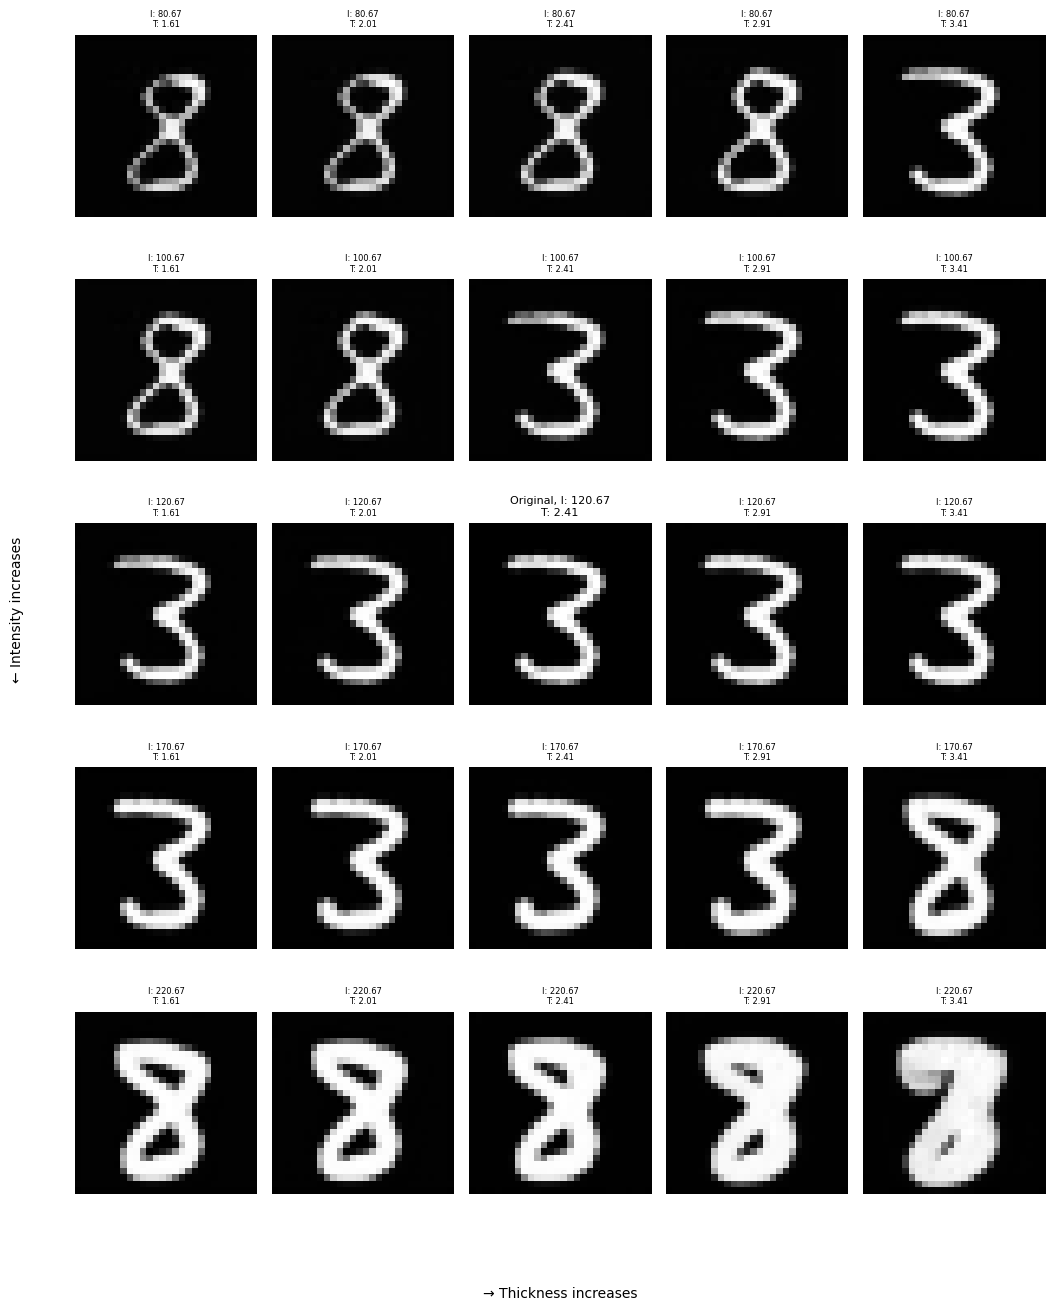

In [38]:
visualize_edit_grid(images, editted_images, intensity_values, thickness_values)

### 1.2.3 1枚の画像に対して介入条件は固定でガイダンススケールを変化させる

In [ ]:
# 0~4.0まで

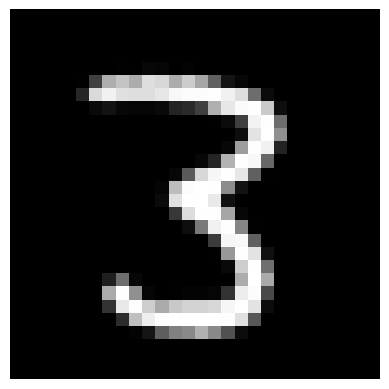

In [40]:
plt.imshow(images[0].squeeze(), cmap='gray')
plt.axis('off')
plt.show()

In [41]:
metrics

tensor([[120.6711,   2.4086]], device='cuda:0')

In [46]:
intervened_metrics = torch.Tensor([[120.6711,   3.5086]]).to(device)

In [53]:
from diffusion.utils.diffusion_utils import DiffusionUtils
import numpy as np

eta=0.0
interval=1
cond=metrics
ws=[0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0]
batch_size=1
image_size=28
timesteps=500
input_img=images.unsqueeze(1).to(device)
utils = DiffusionUtils(timesteps=timesteps)

# 5×5のリスト
editted_images = []
for w in ws:
    noises = utils.ddim_p_sample_loop(denoise_model, eta, interval, metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=True, input_img=input_img)
    imgs = utils.ddim_p_sample_loop(denoise_model, eta, interval, intervened_metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=False, noise=noises[-1])
    editted_images.append(imgs[-1].cpu().detach().numpy())

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

...

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

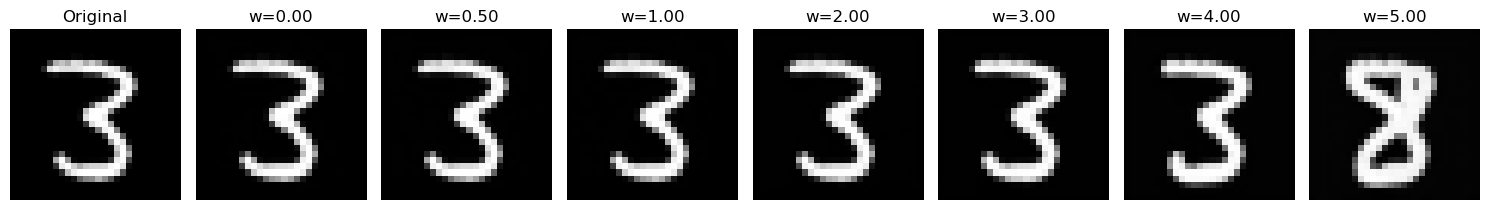

In [54]:
import matplotlib.pyplot as plt
import numpy as np


fig, axes = plt.subplots(1, len(ws)+1, figsize=(15, 3 * len(ws)))
axes[0].imshow(images[0].squeeze(), cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')
for i, w in enumerate(ws):
    axes[i+1].imshow(editted_images[i].squeeze(), cmap='gray')
    axes[i+1].set_title(f"w={w:.2f}")
    axes[i+1].axis('off')
plt.tight_layout()
plt.show()